<a href="https://colab.research.google.com/github/SamiraKheradmand/IASC-ASCE-Transformer-SHM/blob/main/notebooks/02_split_methods/chronological/Chronological_transformer_confound_controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import scipy.io as sio
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive/ASCE_IASC"

figures					random_window_split_seed42.csv
MAT_data				Results
processed_zero_mean			txt_all_15_sensors
PSO_results				txt_selected_sensors
random_block_assignment_45s_seed42.csv


In [ ]:
from pathlib import Path

import numpy as np
import scipy.io as sio


# مسیر فایل‌ها
DATA_DIR = Path("/content/drive/MyDrive/ASCE_IASC/MAT_data")

# فقط 15 سنسور واقعی سازه
CHANNELS = [f"DA{i:02d}" for i in range(1, 16)]

# پیدا کردن فایل‌های 9 حالت سازه
mat_files = sorted(DATA_DIR.glob("shm*.mat"))

print("Folder exists:", DATA_DIR.exists())
print("Number of files:", len(mat_files))
print("Number of channels:", len(CHANNELS))


def load_ambient_file(file_path):
    """
    خواندن یک فایل Ambient از داده‌های IASC-ASCE
    """

    mat = sio.loadmat(file_path,squeeze_me=True,struct_as_record=False)

    dasy = mat["dasy"]
    dasy_dscr = mat["dasy_dscr"]
    fs = float(mat["fsdasy"])

    signals = []
    descriptions = []

    for i, channel in enumerate(CHANNELS, start=1):

        signal = np.asarray(getattr(dasy, channel)).reshape(-1)

        description_name = f"DAdscr{i:02d}"
        description = getattr(dasy_dscr, description_name)

        signals.append(signal)
        descriptions.append(description)

    # شکل خروجی:
    # (تعداد نمونه‌های زمانی، تعداد سنسورها)
    X_raw = np.column_stack(signals)

    return X_raw, fs, descriptions

Folder exists: True
Number of files: 9
Number of channels: 15


In [ ]:
all_cases = {}

for file_path in mat_files:

    case_name = file_path.stem
    case_number = int(case_name[3:5])

    X_raw, fs, descriptions = load_ambient_file(file_path)

    all_cases[case_name] = {
        "X_raw": X_raw,
        "fs": fs,
        "channels": CHANNELS.copy(),
        "descriptions": descriptions,
        "case_number": case_number,
        "label": case_number - 1,
        "file_path": file_path
    }

    print(
        f"{case_name} | "
        f"shape: {X_raw.shape} | "
        f"fs: {fs} Hz | "
        f"label: {case_number - 1}"

    )
print( f"description: {pd.DataFrame(descriptions)}")

shm01a | shape: (60000, 15) | fs: 200.0 Hz | label: 0
shm02a | shape: (60000, 15) | fs: 200.0 Hz | label: 1
shm03a | shape: (60000, 15) | fs: 200.0 Hz | label: 2
shm04a | shape: (60000, 15) | fs: 200.0 Hz | label: 3
shm05a | shape: (60000, 15) | fs: 200.0 Hz | label: 4
shm06a | shape: (45568, 15) | fs: 200.0 Hz | label: 5
shm07a | shape: (180000, 15) | fs: 200.0 Hz | label: 6
shm08a | shape: (180000, 15) | fs: 200.0 Hz | label: 7
shm09a | shape: (180000, 15) | fs: 200.0 Hz | label: 8
description:                                                0
0   Base West side - EPI sensor X direction (N+)
1      Base Center - EPI sensor Y direction (W+)
2   Base East side - EPI sensor X direction (N+)
3    1st Floor - N/S EPI Sensor at West end (N+)
4      1st Floor - E/W FBA Sensor at Center (W+)
5    1st Floor - N/S FBA Sensor at East end (N+)
6    2nd Floor - N/S FBA Sensor at West end (N+)
7      2nd Floor - E/W EPI Sensor at Center (W+)
8    2nd Floor - N/S EPI Sensor at East end (N+)
9    3rd

In [ ]:
print(all_cases["shm01a"]["X_raw"].shape)
print(all_cases["shm01a"]["channels"])


(60000, 15)
['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']


In [ ]:
# ============================================================
# Control 2A: Same-session / same-layout subset
# Cases 1 to 5
# ============================================================

control_cases = [
    "shm01a",
    "shm02a",
    "shm03a",
    "shm04a",
    "shm05a",
    "shm06a",
    "shm07a",
    "shm08a",
    "shm09a",

]

all_cases = {
    case_name: all_cases[case_name]
    for case_name in control_cases
}

print("Control 2A cases:")
print(list(all_cases.keys()))

print("\nNumber of classes:", len(all_cases))

Control 2A cases:
['shm01a', 'shm02a', 'shm03a', 'shm04a', 'shm05a', 'shm06a', 'shm07a', 'shm08a', 'shm09a']

Number of classes: 9


In [ ]:
# ============================================================
# Step 2: Chronological split and Butterworth high-pass filter
# Filter is applied separately to Train, Validation and Test
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt


# ----------------------------
# Split settings
# ----------------------------
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

In [ ]:
train_data = {}
val_data = {}
test_data = {}

split_report = []
split_bounds = {}

for case_name in sorted(all_cases.keys()):

    # Raw data
    X = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X)

    gap_size = int(GAP_SEC * fs)
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Chronological split boundaries
    # ----------------------------
    train_end = int(TRAIN_RATIO * n_samples)

    val_start = train_end + gap_size
    val_end = val_start + int(VAL_RATIO * n_samples)

    test_start = val_end + gap_size

    # ----------------------------
    # Save original timeline boundaries for audit
    # end indices are exclusive
    # ----------------------------
    split_bounds[case_name] = {

        "fs": fs,
        "n_samples": n_samples,

        "train": {
            "raw_start": 0,
            "raw_end": train_end,
            "usable_start": edge_size,
            "usable_end": train_end - edge_size
        },

        "val": {
            "raw_start": val_start,
            "raw_end": val_end,
            "usable_start": val_start + edge_size,
            "usable_end": val_end - edge_size
        },

        "test": {
            "raw_start": test_start,
            "raw_end": n_samples,
            "usable_start": test_start + edge_size,
            "usable_end": n_samples - edge_size
        }
    }

    if test_start >= n_samples:
        raise ValueError(f"{case_name}: signal is too short for this gap.")

    # ----------------------------
    # Split raw signal
    # ----------------------------
    X_train_raw = X[:train_end]
    X_val_raw = X[val_start:val_end]
    X_test_raw = X[test_start:]

    # Check split lengths
    if min(len(X_train_raw), len(X_val_raw), len(X_test_raw)) <= 2 * edge_size:
        raise ValueError(f"{case_name}: EDGE_SEC is too large.")

    # ----------------------------
    # Filter each split separately
    # ----------------------------
    X_train_filtered = highpass_filter(X_train_raw, fs)
    X_val_filtered  = highpass_filter(X_val_raw, fs)
    X_test_filtered = highpass_filter(X_test_raw, fs)

    # ----------------------------
    # Remove filter edges
    # ----------------------------
    X_train_filtered = X_train_filtered[edge_size:-edge_size]
    X_val_filtered  = X_val_filtered[edge_size:-edge_size]
    X_test_filtered = X_test_filtered[edge_size:-edge_size]

    # ----------------------------
    # Save filtered data
    # ----------------------------
    train_data[case_name] = X_train_filtered
    val_data[case_name] = X_val_filtered
    test_data[case_name] = X_test_filtered

    split_report.append({
        "case": case_name,
        "total_samples": n_samples,

        "train_samples_filtered": len(X_train_filtered),
        "val_samples_filtered": len(X_val_filtered),
        "test_samples_filtered":len(X_test_filtered),
        "train_duration_sec":len(X_train_filtered) / fs,
        "val_duration_sec":len(X_val_filtered) / fs,
        "test_duration_sec":len(X_test_filtered) / fs
    })


split_report_df = pd.DataFrame(split_report)

display(split_report_df)

,case,total_samples,train_samples_filtered,val_samples_filtered,test_samples_filtered,train_duration_sec,val_duration_sec,test_duration_sec
0,shm01a,60000,35200,11200,11200,176.0,56.000,56.000
1,shm02a,60000,35200,11200,11200,176.0,56.000,56.000
2,shm03a,60000,35200,11200,11200,176.0,56.000,56.000
3,shm04a,60000,35200,11200,11200,176.0,56.000,56.000
4,shm05a,60000,35200,11200,11200,176.0,56.000,56.000
5,shm06a,45568,26540,8313,8315,132.7,41.565,41.575
6,shm07a,180000,107200,35200,35200,536.0,176.000,176.000
7,shm08a,180000,107200,35200,35200,536.0,176.000,176.000
8,shm09a,180000,107200,35200,35200,536.0,176.000,176.000


In [ ]:
# split_bounds["shm01a"]

In [ ]:
for case_name in sorted(train_data.keys()):

    print(f"{case_name} | "
          f"Train: {train_data[case_name].shape} | "
          f"Validation: {val_data[case_name].shape} | "
          f"Test: {test_data[case_name].shape}" )

shm01a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm02a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm03a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm04a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm05a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm06a | Train: (26540, 15) | Validation: (8313, 15) | Test: (8315, 15)
shm07a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)
shm08a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)
shm09a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)


In [ ]:
filter_check = []

for case_name in sorted(all_cases.keys()):

    raw_train_end = int(TRAIN_RATIO * len(all_cases[case_name]["X_raw"]))
    X_train_raw = all_cases[case_name]["X_raw"][:raw_train_end]
    X_train_filtered = train_data[case_name]

    filter_check.append({
        "case": case_name,
        "mean_abs_raw": np.mean(np.abs(np.mean(X_train_raw, axis=0))),
        "mean_abs_filtered": np.mean(np.abs(np.mean(X_train_filtered,axis=0)))
    })

filter_check_df = pd.DataFrame(filter_check)
display(filter_check_df)

,case,mean_abs_raw,mean_abs_filtered
0,shm01a,0.001260,1.125002e-06
1,shm02a,0.001564,2.848653e-07
2,shm03a,0.000955,3.674356e-07
3,shm04a,0.001096,3.553501e-07
4,shm05a,0.001285,8.238489e-07
5,shm06a,0.001239,2.023264e-06
6,shm07a,0.001139,9.591543e-08
7,shm08a,0.001083,9.232525e-08
8,shm09a,0.001077,1.732560e-07


In [ ]:
import re
# ============================================================
# Control 1: Stable-layout sensor subset
# ============================================================

stable_sensor_names = [
  #  "DA01", "DA02", "DA03",
 "DA04",
    "DA05","DA07", "DA08",
    "DA10", "DA11",
    "DA13", "DA14"
]

selected_sensor_indices = [
    CHANNELS.index(sensor_name)
    for sensor_name in stable_sensor_names
]

selected_sensor_names = [
    CHANNELS[i]
    for i in selected_sensor_indices
]

print("Control 1 stable sensors:")
print(selected_sensor_names)

print("\nNumber of sensors:", len(selected_sensor_names))

Control 1 stable sensors:
['DA04', 'DA05', 'DA07', 'DA08', 'DA10', 'DA11', 'DA13', 'DA14']

Number of sensors: 8


In [ ]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

# selected_sensor_indices = [8, 11, 13, 14]  # DA09, DA12, DA14, DA15
# selected_sensor_indices = [0,3]
# selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14]

# selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]
# stable_sensor_names = [
#     "DA04", "DA05",
#     "DA07", "DA08",
#     "DA10", "DA11",
#     "DA13", "DA14"]

train_selected = {}
val_selected = {}
test_selected = {}

for case_name in train_data.keys():
    train_selected[case_name] = train_data[case_name][:, selected_sensor_indices]
    val_selected[case_name]   = val_data[case_name][:, selected_sensor_indices]
    test_selected[case_name]  = test_data[case_name][:, selected_sensor_indices]

print("Selected sensors:", selected_sensor_names)

for case_name in sorted(train_selected.keys()):
    print(
        f"Case {case_name}: "
        f"train={train_selected[case_name].shape}, "
        f"val={val_selected[case_name].shape}, "
        f"test={test_selected[case_name].shape}"
    )

Selected sensors: ['DA04', 'DA05', 'DA07', 'DA08', 'DA10', 'DA11', 'DA13', 'DA14']
Case shm01a: train=(35200, 8), val=(11200, 8), test=(11200, 8)
Case shm02a: train=(35200, 8), val=(11200, 8), test=(11200, 8)
Case shm03a: train=(35200, 8), val=(11200, 8), test=(11200, 8)
Case shm04a: train=(35200, 8), val=(11200, 8), test=(11200, 8)
Case shm05a: train=(35200, 8), val=(11200, 8), test=(11200, 8)
Case shm06a: train=(26540, 8), val=(8313, 8), test=(8315, 8)
Case shm07a: train=(107200, 8), val=(35200, 8), test=(35200, 8)
Case shm08a: train=(107200, 8), val=(35200, 8), test=(35200, 8)
Case shm09a: train=(107200, 8), val=(35200, 8), test=(35200, 8)


In [ ]:
# ============================================================
# Step 4: Global train-based normalization
# One mean and standard deviation for each selected sensor
# ============================================================

EPS = 1e-8
train_concat = np.concatenate(
    [train_selected[case_name] for case_name in sorted(train_selected.keys())],axis=0)


print("Combined Train shape:", train_concat.shape)
train_mean = train_concat.mean(axis=0,keepdims=True,dtype=np.float64)
train_std = train_concat.std(axis=0,keepdims=True,dtype=np.float64)


# Prevent division by zero
train_std_safe = np.where(train_std < EPS,1.0,train_std)


print("Train mean shape:", train_mean.shape)
print("Train std shape:", train_std_safe.shape)

Combined Train shape: (524140, 8)
Train mean shape: (1, 8)
Train std shape: (1, 8)


In [ ]:
train_norm = {}
val_norm = {}
test_norm = {}


for case_name in sorted(train_selected.keys()):

    train_norm[case_name] = ((train_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    val_norm[case_name]   = ((val_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    test_norm[case_name]  = ((test_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)


print("Normalization completed.")

Normalization completed.


In [ ]:
train_norm_concat = np.concatenate(
    [ train_norm[case_name] for case_name in sorted(train_norm.keys())],axis=0)

normalized_train_mean = train_norm_concat.mean(axis=0)
normalized_train_std = train_norm_concat.std(axis=0)

print("Train mean after normalization:")
print(np.round(normalized_train_mean,5))

print("\nTrain std after normalization:")
print(np.round(normalized_train_std,5))

Train mean after normalization:
[-0.  0. -0. -0. -0.  0.  0. -0.]

Train std after normalization:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# ============================================================
# Step 5: Create non-overlapping time windows
# ============================================================

WINDOW_SIZE = 512
STEP_SIZE = 512

FS_DASY = 200

print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS_DASY, "seconds")
print("Step size:", STEP_SIZE, "samples")
print("Step duration:", STEP_SIZE / FS_DASY, "seconds")

Window size: 512 samples
Window duration: 2.56 seconds
Step size: 512 samples
Step duration: 2.56 seconds


In [ ]:
# ============================================================
# Label mapping for the selected control cases
# ============================================================

label_map = {
    case_name: i
    for i, case_name in enumerate(sorted(train_norm.keys()))
}

print("Label mapping:")
print(label_map)

Label mapping:
{'shm01a': 0, 'shm02a': 1, 'shm03a': 2, 'shm04a': 3, 'shm05a': 4, 'shm06a': 5, 'shm07a': 6, 'shm08a': 7, 'shm09a': 8}


In [ ]:
def make_windows(split_data, split_name):

    all_windows = []
    all_labels = []
    meta_rows = []

    for case_name in sorted(split_data.keys()):

        X = split_data[case_name]

        n_samples = len(X)

        # shm01a -> scenario 1 -> label 0
        scenario_number = int(case_name[3:5])
        # label = scenario_number - 1
        label = label_map[case_name]

        # Start of usable data in the original recording
        global_origin = split_bounds[case_name][split_name]["usable_start"]

        window_number = 0

        for start in range(0, n_samples - WINDOW_SIZE + 1, STEP_SIZE):

            end = start + WINDOW_SIZE

            window = X[start:end, :]

            all_windows.append(window)
            all_labels.append(label)

            global_start = global_origin + start
            global_end = global_origin + end

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "window": window_number,
                "split": split_name,
                "start_sample": start,
                "end_sample": end,
                "global_start_sample": global_start,
                "global_end_sample": global_end
            })

            window_number += 1

    if len(all_windows) == 0:
        raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows, axis=0).astype(np.float32)

    y_labels = np.array(all_labels, dtype=np.int64)

    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [ ]:
X_train, y_train, train_meta_df = make_windows(train_norm, "train")

X_val, y_val, val_meta_df = make_windows(val_norm, "val")

X_test, y_test, test_meta_df = make_windows(test_norm, "test")

In [ ]:
display(train_meta_df.head(3))
display(val_meta_df.head(3))
display(test_meta_df.head(3))

,case,scenario,label,window,split,start_sample,end_sample,global_start_sample,global_end_sample
0,shm01a,1,0,0,train,0,512,400,912
1,shm01a,1,0,1,train,512,1024,912,1424
2,shm01a,1,0,2,train,1024,1536,1424,1936


,case,scenario,label,window,split,start_sample,end_sample,global_start_sample,global_end_sample
0,shm01a,1,0,0,val,0,512,36400,36912
1,shm01a,1,0,1,val,512,1024,36912,37424
2,shm01a,1,0,2,val,1024,1536,37424,37936


,case,scenario,label,window,split,start_sample,end_sample,global_start_sample,global_end_sample
0,shm01a,1,0,0,test,0,512,48400,48912
1,shm01a,1,0,1,test,512,1024,48912,49424
2,shm01a,1,0,2,test,1024,1536,49424,49936


In [ ]:
# ============================================================
# Structural Audit 1: Combine window metadata
# ============================================================

audit_meta_df = pd.concat(
    [train_meta_df, val_meta_df, test_meta_df],
    ignore_index=True
)

print("Total windows:", len(audit_meta_df))

display(audit_meta_df.head())

Total windows: 1668


,case,scenario,label,window,split,start_sample,end_sample,global_start_sample,global_end_sample
0,shm01a,1,0,0,train,0,512,400,912
1,shm01a,1,0,1,train,512,1024,912,1424
2,shm01a,1,0,2,train,1024,1536,1424,1936
3,shm01a,1,0,3,train,1536,2048,1936,2448
4,shm01a,1,0,4,train,2048,2560,2448,2960


In [ ]:
# ============================================================
# Structural Audit 2: Basic sanity checks
# ============================================================

# 1. Metadata length must match window arrays
assert len(train_meta_df) == len(X_train)
assert len(val_meta_df) == len(X_val)
assert len(test_meta_df) == len(X_test)

# 2. Every window must have exactly WINDOW_SIZE samples
window_lengths = (
    audit_meta_df["global_end_sample"]
    - audit_meta_df["global_start_sample"]
)

assert (window_lengths == WINDOW_SIZE).all()

# 3. Global positions must be valid
for case_name in sorted(all_cases.keys()):

    n_samples = len(all_cases[case_name]["X_raw"])

    case_meta = audit_meta_df[
        audit_meta_df["case"] == case_name
    ]

    assert (case_meta["global_start_sample"] >= 0).all()
    assert (case_meta["global_end_sample"] <= n_samples).all()

print("All basic structural checks passed.")

All basic structural checks passed.


In [ ]:
# ============================================================
# Structural Audit 3: Check overlap within each split
# ============================================================

internal_overlap_rows = []

for case_name in sorted(all_cases.keys()):

    for split_name in ["train", "val", "test"]:

        temp = audit_meta_df[
            (audit_meta_df["case"] == case_name) &
            (audit_meta_df["split"] == split_name)
        ].sort_values("global_start_sample")

        starts = temp["global_start_sample"].to_numpy()
        ends = temp["global_end_sample"].to_numpy()

        overlap_count = 0

        if len(temp) > 1:
            overlap_count = np.sum(starts[1:] < ends[:-1])

        internal_overlap_rows.append({
            "case": case_name,
            "split": split_name,
            "overlap_pairs": int(overlap_count)
        })

internal_overlap_df = pd.DataFrame(internal_overlap_rows)

display(internal_overlap_df)

print(
    "Total internal overlap pairs:",
    internal_overlap_df["overlap_pairs"].sum()
)

,case,split,overlap_pairs
0,shm01a,train,0
1,shm01a,val,0
2,shm01a,test,0
3,shm02a,train,0
4,shm02a,val,0
5,shm02a,test,0
6,shm03a,train,0
7,shm03a,val,0
8,shm03a,test,0
9,shm04a,train,0


Total internal overlap pairs: 0


In [ ]:
# ============================================================
# Structural Audit 4: Cross-split raw sample overlap
# ============================================================

split_pairs = [
    ("train", "val"),
    ("train", "test"),
    ("val", "test")
]

overlap_rows = []

for case_name in sorted(all_cases.keys()):
    case_meta = audit_meta_df[audit_meta_df["case"] == case_name]

    for split_a, split_b in split_pairs:

        meta_a = case_meta[case_meta["split"] == split_a]
        meta_b = case_meta[case_meta["split"] == split_b]

        overlap_samples = 0
        windows_a_with_overlap = set()
        windows_b_with_overlap = set()

        for idx_a, row_a in meta_a.iterrows():

            for idx_b, row_b in meta_b.iterrows():

                overlap = max(
                    0,
                    min(row_a["global_end_sample"],row_b["global_end_sample"])
                    -
                    max(row_a["global_start_sample"],row_b["global_start_sample"]))

                if overlap > 0:

                    overlap_samples += overlap

                    windows_a_with_overlap.add(idx_a)
                    windows_b_with_overlap.add(idx_b)

        overlap_rows.append({
            "case": case_name,
            "split_a": split_a,
            "split_b": split_b,
            "overlap_samples": int(overlap_samples),
            "windows_a_with_overlap": len(windows_a_with_overlap),
            "windows_b_with_overlap": len(windows_b_with_overlap)
        })


cross_split_overlap_df = pd.DataFrame(overlap_rows)

display(cross_split_overlap_df)

,case,split_a,split_b,overlap_samples,windows_a_with_overlap,windows_b_with_overlap
0,shm01a,train,val,0,0,0
1,shm01a,train,test,0,0,0
2,shm01a,val,test,0,0,0
3,shm02a,train,val,0,0,0
4,shm02a,train,test,0,0,0
5,shm02a,val,test,0,0,0
6,shm03a,train,val,0,0,0
7,shm03a,train,test,0,0,0
8,shm03a,val,test,0,0,0
9,shm04a,train,val,0,0,0


In [ ]:
# ============================================================
# Structural Audit 5: Cross-split overlap summary
# ============================================================

overlap_summary_df = (
    cross_split_overlap_df
    .groupby(["split_a", "split_b"], as_index=False)
    [
        [
            "overlap_samples",
            "windows_a_with_overlap",
            "windows_b_with_overlap"
        ]
    ]
    .sum()
)

display(overlap_summary_df)

,split_a,split_b,overlap_samples,windows_a_with_overlap,windows_b_with_overlap
0,train,test,0,0,0
1,train,val,0,0,0
2,val,test,0,0,0


In [ ]:
# ============================================================
# Structural Audit 6: Window counts by scenario and split
# ============================================================

window_count_df = (
    audit_meta_df
    .groupby(["scenario", "split"])
    .size()
    .unstack(fill_value=0)
)

window_count_df = window_count_df[["train", "val", "test"]]

display(window_count_df)

split,train,val,test
scenario,,,
1,68,21,21
2,68,21,21
3,68,21,21
4,68,21,21
5,68,21,21
6,51,16,16
7,209,68,68
8,209,68,68
9,209,68,68


In [ ]:
print("Total windows per split:")

display(
    audit_meta_df["split"]
    .value_counts()
    .reindex(["train", "val", "test"])
)

Total windows per split:


,count
split,
train,1018
val,325
test,325


In [ ]:
# ============================================================
# Structural Audit 7: Test-to-Train temporal distance
# ============================================================

temporal_rows = []

for case_name in sorted(all_cases.keys()):

    train_case = train_meta_df[
        train_meta_df["case"] == case_name
    ].reset_index(drop=True)

    test_case = test_meta_df[
        test_meta_df["case"] == case_name
    ].reset_index(drop=True)

    fs = all_cases[case_name]["fs"]

    train_starts = train_case["global_start_sample"].to_numpy()
    train_ends = train_case["global_end_sample"].to_numpy()

    for _, test_row in test_case.iterrows():

        test_start = test_row["global_start_sample"]
        test_end = test_row["global_end_sample"]

        # Distance between the Test interval and every Train interval
        distances = np.maximum(
            0,
            np.maximum(
                train_starts - test_end,
                test_start - train_ends
            )
        )

        nearest_pos = np.argmin(distances)
        min_distance = int(distances[nearest_pos])

        temporal_rows.append({
            "case": case_name,
            "scenario": test_row["scenario"],
            "test_window": test_row["window"],
            "nearest_train_window": train_case.iloc[nearest_pos]["window"],
            "distance_samples": min_distance,
            "distance_sec": min_distance / fs
        })


temporal_distance_df = pd.DataFrame(temporal_rows)

display(temporal_distance_df.head())

,case,scenario,test_window,nearest_train_window,distance_samples,distance_sec
0,shm01a,1,0,67,13184,65.92
1,shm01a,1,1,67,13696,68.48
2,shm01a,1,2,67,14208,71.04
3,shm01a,1,3,67,14720,73.60
4,shm01a,1,4,67,15232,76.16


In [ ]:
# ============================================================
# Temporal distance summary by scenario
# ============================================================

temporal_by_case_df = (
    temporal_distance_df
    .groupby(["case", "scenario"])["distance_sec"]
    .agg(["min", "median", "mean"])
    .reset_index()
)

display(temporal_by_case_df)

,case,scenario,min,median,mean
0,shm01a,1,65.920,91.520,91.520
1,shm02a,2,65.920,91.520,91.520
2,shm03a,3,65.920,91.520,91.520
3,shm04a,4,65.920,91.520,91.520
4,shm05a,5,65.920,91.520,91.520
5,shm06a,6,51.705,70.905,70.905
6,shm07a,7,184.960,270.720,270.720
7,shm08a,8,184.960,270.720,270.720
8,shm09a,9,184.960,270.720,270.720


In [ ]:
# Overall temporal distance summary

overall_temporal_summary = pd.DataFrame({
    "minimum_sec": [temporal_distance_df["distance_sec"].min()],
    "median_sec": [temporal_distance_df["distance_sec"].median()],
    "mean_sec": [temporal_distance_df["distance_sec"].mean()]
})

display(overall_temporal_summary)

,minimum_sec,median_sec,mean_sec
0,51.705,218.24,202.987569


In [ ]:
# ============================================================
# Structural Audit 8: Test windows adjacent to Train
# ============================================================

adjacent_rows = []

for case_name in sorted(all_cases.keys()):

    train_case = train_meta_df[
        train_meta_df["case"] == case_name
    ]

    test_case = test_meta_df[
        test_meta_df["case"] == case_name
    ]

    train_starts = train_case["global_start_sample"].to_numpy()
    train_ends = train_case["global_end_sample"].to_numpy()

    adjacent_count = 0

    for _, test_row in test_case.iterrows():

        test_start = test_row["global_start_sample"]
        test_end = test_row["global_end_sample"]

        is_adjacent = (
            np.any(train_ends == test_start) or
            np.any(train_starts == test_end)
        )

        if is_adjacent:
            adjacent_count += 1

    total_test = len(test_case)

    adjacent_rows.append({
        "case": case_name,
        "scenario": int(case_name[3:5]),
        "test_windows": total_test,
        "adjacent_test_windows": adjacent_count,
        "adjacent_percent": 100 * adjacent_count / total_test
    })


adjacent_df = pd.DataFrame(adjacent_rows)

display(adjacent_df)

,case,scenario,test_windows,adjacent_test_windows,adjacent_percent
0,shm01a,1,21,0,0.0
1,shm02a,2,21,0,0.0
2,shm03a,3,21,0,0.0
3,shm04a,4,21,0,0.0
4,shm05a,5,21,0,0.0
5,shm06a,6,16,0,0.0
6,shm07a,7,68,0,0.0
7,shm08a,8,68,0,0.0
8,shm09a,9,68,0,0.0


In [ ]:
# Overall adjacent Test percentage

total_test_windows = adjacent_df["test_windows"].sum()
total_adjacent = adjacent_df["adjacent_test_windows"].sum()

overall_adjacent_percent = (
    100 * total_adjacent / total_test_windows
)

print("Total Test windows:", total_test_windows)
print("Adjacent Test windows:", total_adjacent)
print(f"Adjacent Test windows (%): {overall_adjacent_percent:.2f}")

Total Test windows: 325
Adjacent Test windows: 0
Adjacent Test windows (%): 0.00


In [ ]:
# ============================================================
# Structural Audit 9: Raw data utilization
# ============================================================

utilization_rows = []

for case_name in sorted(all_cases.keys()):

    fs = all_cases[case_name]["fs"]
    total_raw = len(all_cases[case_name]["X_raw"])

    # Samples remaining after edge trimming
    retained_after_trim = (
        len(train_data[case_name])
        + len(val_data[case_name])
        + len(test_data[case_name])
    )

    # Samples actually used inside complete windows
    train_used = len(
        train_meta_df[train_meta_df["case"] == case_name]
    ) * WINDOW_SIZE

    val_used = len(
        val_meta_df[val_meta_df["case"] == case_name]
    ) * WINDOW_SIZE

    test_used = len(
        test_meta_df[test_meta_df["case"] == case_name]
    ) * WINDOW_SIZE

    total_used = train_used + val_used + test_used

    edge_loss = total_raw - retained_after_trim
    window_remainder_loss = retained_after_trim - total_used

    utilization_rows.append({
        "case": case_name,
        "total_raw_samples": total_raw,
        "retained_after_trim": retained_after_trim,
        "used_in_windows": total_used,
        "edge_loss_samples": edge_loss,
        "window_remainder_loss": window_remainder_loss,
        "used_percent": 100 * total_used / total_raw
    })

utilization_df = pd.DataFrame(utilization_rows)

display(utilization_df)

,case,total_raw_samples,retained_after_trim,used_in_windows,edge_loss_samples,window_remainder_loss,used_percent
0,shm01a,60000,57600,56320,2400,1280,93.866667
1,shm02a,60000,57600,56320,2400,1280,93.866667
2,shm03a,60000,57600,56320,2400,1280,93.866667
3,shm04a,60000,57600,56320,2400,1280,93.866667
4,shm05a,60000,57600,56320,2400,1280,93.866667
5,shm06a,45568,43168,42496,2400,672,93.258427
6,shm07a,180000,177600,176640,2400,960,98.133333
7,shm08a,180000,177600,176640,2400,960,98.133333
8,shm09a,180000,177600,176640,2400,960,98.133333


In [ ]:
total_raw = utilization_df["total_raw_samples"].sum()
total_used = utilization_df["used_in_windows"].sum()

overall_used_percent = 100 * total_used / total_raw

print("Total raw samples:", total_raw)
print("Samples used in model windows:", total_used)
print(f"Overall raw data used (%): {overall_used_percent:.2f}")

Total raw samples: 885568
Samples used in model windows: 854016
Overall raw data used (%): 96.44


In [ ]:
# ============================================================
# Similarity Audit 1A: Create unnormalized audit windows
# High-pass + edge trim + selected sensors
# ============================================================

X_train_audit, y_train_audit, train_audit_meta = make_windows(train_selected, "train")
X_val_audit, y_val_audit, val_audit_meta = make_windows(val_selected, "val")
X_test_audit, y_test_audit, test_audit_meta = make_windows(test_selected, "test")

print("Train:", X_train_audit.shape)
print("Val:  ", X_val_audit.shape)
print("Test: ", X_test_audit.shape)

Train: (1018, 512, 8)
Val:   (325, 512, 8)
Test:  (325, 512, 8)


In [ ]:
# ============================================================
# Similarity Audit 1B: Statistical features
# Output shape: Windows x 4 Features x 12 Sensors
# ============================================================

from scipy.stats import kurtosis

feature_names = [
    "RMS",
    "STD",
    "Peak-to-peak",
    "Kurtosis"
]


def extract_stat_features(X_windows):

    n_windows = X_windows.shape[0]
    n_sensors = X_windows.shape[2]

    features = np.zeros((n_windows, 4, n_sensors), dtype=np.float64 )

    for i in range(n_windows):

        for j in range(n_sensors):

            x = X_windows[i, :, j]

            features[i, 0, j] = np.sqrt(np.mean(x ** 2))
            features[i, 1, j] = np.std(x)
            features[i, 2, j] = np.ptp(x)
            features[i, 3, j] = kurtosis(
                x,
                fisher=False,
                bias=False
            )

    return features

In [ ]:
train_features = extract_stat_features(X_train_audit)
val_features = extract_stat_features(X_val_audit)
test_features = extract_stat_features(X_test_audit)

print("Train:", train_features.shape)
print("Val:  ", val_features.shape)
print("Test: ", test_features.shape)

Train: (1018, 4, 8)
Val:   (325, 4, 8)
Test:  (325, 4, 8)


In [ ]:
example_df = pd.DataFrame(
    train_features[0],
    index=feature_names,
    columns=selected_sensor_names
)

display(example_df)

,DA04,DA05,DA07,DA08,DA10,DA11,DA13,DA14
RMS,0.000161,0.000939,0.000121,0.000963,0.000101,0.000298,0.000244,0.000931
STD,0.000158,0.000938,0.000121,0.000963,0.000101,0.000297,0.000243,0.000930
Peak-to-peak,0.000728,0.003837,0.000661,0.003862,0.000570,0.001361,0.001144,0.003456
Kurtosis,2.067173,1.865919,2.362283,1.791425,2.638181,2.280525,2.194785,1.639057


In [ ]:
# ============================================================
# Similarity Audit 1C: Train-based feature standardization
# Statistics shape: 4 Features x 12 Sensors
# ============================================================

feature_mean = train_features.mean(axis=0)
feature_std = train_features.std(axis=0)

# Avoid division by zero
feature_std[feature_std == 0] = 1.0

print("Feature mean shape:", feature_mean.shape)
print("Feature std shape: ", feature_std.shape)

Feature mean shape: (4, 8)
Feature std shape:  (4, 8)


In [ ]:
train_features_scaled = (train_features - feature_mean) / feature_std
val_features_scaled = (val_features - feature_mean) / feature_std
test_features_scaled = (test_features - feature_mean) / feature_std

print("Train:", train_features_scaled.shape)
print("Val:  ", val_features_scaled.shape)
print("Test: ", test_features_scaled.shape)

Train: (1018, 4, 8)
Val:   (325, 4, 8)
Test:  (325, 4, 8)


In [ ]:
# ============================================================
# Similarity Audit 1D: Check feature standardization
# ============================================================

scaled_train_mean = train_features_scaled.mean(axis=0)
scaled_train_std = train_features_scaled.std(axis=0)

print("Maximum absolute Train mean:",
      np.abs(scaled_train_mean).max())

print("Minimum Train std:",
      scaled_train_std.min())

print("Maximum Train std:",
      scaled_train_std.max())

Maximum absolute Train mean: 4.950198731604701e-16
Minimum Train std: 0.9999999999999988
Maximum Train std: 1.0000000000000013


In [ ]:
# ============================================================
# Similarity Audit 2A: Test-to-Train nearest-neighbor distance
# Same scenario only
# ============================================================

from scipy.spatial.distance import cdist

train_flat = train_features_scaled.reshape(len(train_features_scaled), -1)
test_flat = test_features_scaled.reshape(len(test_features_scaled), -1)

nn_rows = []

for scenario in sorted(train_audit_meta["scenario"].unique()):

    train_mask = train_audit_meta["scenario"].to_numpy() == scenario
    test_mask = test_audit_meta["scenario"].to_numpy() == scenario

    train_case = train_flat[train_mask]
    test_case = test_flat[test_mask]

    train_meta_case = train_audit_meta[train_mask].reset_index(drop=True)
    test_meta_case = test_audit_meta[test_mask].reset_index(drop=True)

    # Test windows x Train windows
    distances = cdist(test_case, train_case, metric="euclidean")

    nearest_idx = distances.argmin(axis=1)
    nearest_dist = distances.min(axis=1)

    for i in range(len(test_case)):

        nn_rows.append({
            "case": test_meta_case.loc[i, "case"],
            "scenario": scenario,
            "test_window": test_meta_case.loc[i, "window"],
            "nearest_train_window": train_meta_case.loc[
                nearest_idx[i], "window"
            ],
            "nn_distance": nearest_dist[i]
        })

feature_nn_df = pd.DataFrame(nn_rows)

display(feature_nn_df.head(20))

,case,scenario,test_window,nearest_train_window,nn_distance
0,shm01a,1,0,55,2.056986
1,shm01a,1,1,0,3.838337
2,shm01a,1,2,53,1.383143
3,shm01a,1,3,55,1.521565
4,shm01a,1,4,3,2.251265
5,shm01a,1,5,11,0.772040
6,shm01a,1,6,61,1.081998
7,shm01a,1,7,60,0.931611
8,shm01a,1,8,55,1.023960
9,shm01a,1,9,64,0.905440


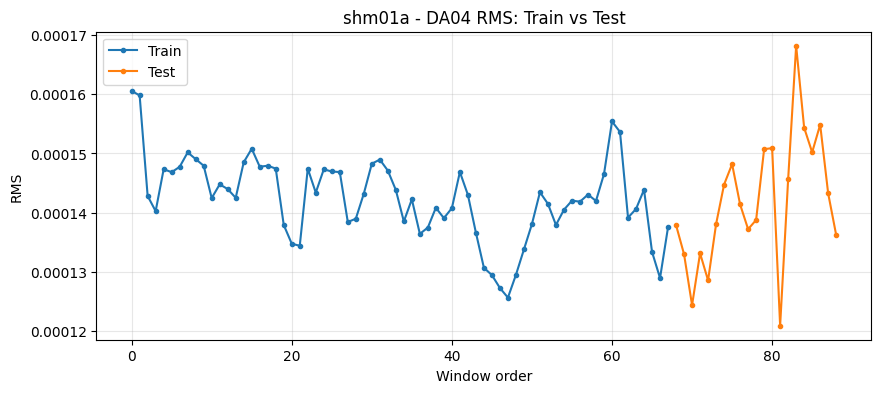

In [ ]:
# ============================================================
# Similarity Audit 2B: Plot one feature
# Example: RMS of DA04 for shm01a
# ============================================================

scenario = 1

feature_idx = 0   # RMS
sensor_idx = 0    # DA04

train_mask = train_audit_meta["scenario"].to_numpy() == scenario
test_mask = test_audit_meta["scenario"].to_numpy() == scenario

train_rms = train_features[train_mask, feature_idx, sensor_idx]
test_rms = test_features[test_mask, feature_idx, sensor_idx]

plt.figure(figsize=(10, 4))

plt.plot(
    range(len(train_rms)),
    train_rms,
    marker="o",
    markersize=3,
    label="Train"
)

plt.plot(
    range(len(train_rms), len(train_rms) + len(test_rms)),
    test_rms,
    marker="o",
    markersize=3,
    label="Test"
)

plt.xlabel("Window order")
plt.ylabel("RMS")
plt.title("shm01a - DA04 RMS: Train vs Test")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# Similarity Audit 2C: Train-Test feature distribution
# Example: shm01a - DA04 RMS
# ============================================================

scenario = 1
feature_idx = 0   # RMS
sensor_idx = 0    # DA04

train_mask = train_audit_meta["scenario"].to_numpy() == scenario
test_mask = test_audit_meta["scenario"].to_numpy() == scenario

train_values = train_features[train_mask, feature_idx, sensor_idx]
test_values = test_features[test_mask, feature_idx, sensor_idx]

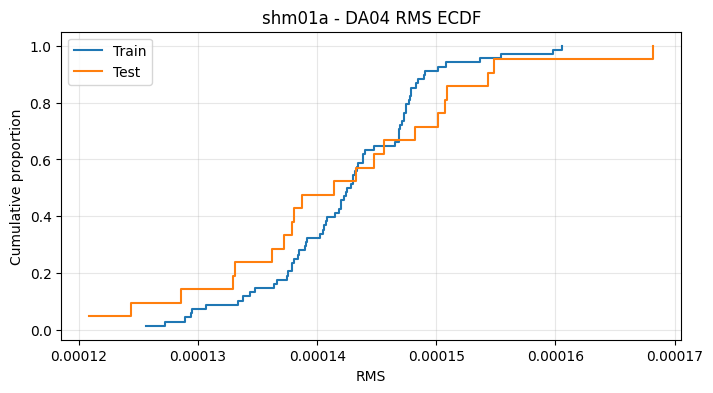

In [ ]:
# ============================================================
# Similarity Audit 2D: ECDF
# Example: shm01a - DA04 RMS
# ============================================================

def ecdf(values):

    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)

    return x, y


train_x, train_y = ecdf(train_values)
test_x, test_y = ecdf(test_values)

plt.figure(figsize=(8, 4))
plt.step(train_x,train_y, where="post",label="Train")
plt.step(test_x,test_y,where="post",label="Test")

plt.xlabel("RMS")
plt.ylabel("Cumulative proportion")
plt.title("shm01a - DA04 RMS ECDF")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

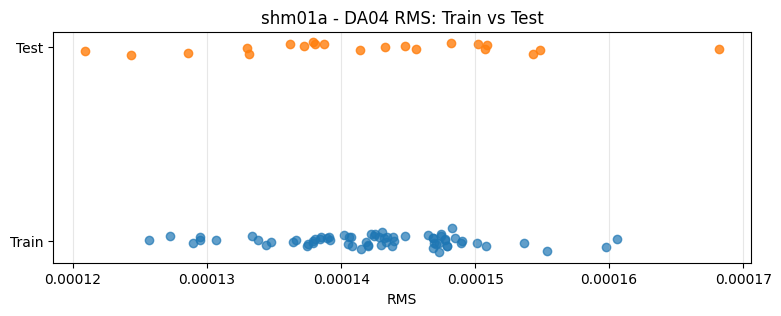

In [ ]:
# ============================================================
# Similarity Audit 2E: Point distribution
# shm01a - DA04 RMS
# ============================================================

plt.figure(figsize=(9, 3))

# Small vertical jitter only for visibility
rng = np.random.default_rng(42)

train_y = rng.normal(0, 0.03, len(train_values))
test_y = rng.normal(1, 0.03, len(test_values))

plt.scatter(train_values,train_y,alpha=0.7,label="Train", color="tab:blue")
plt.scatter(test_values,test_y,alpha=0.8,label="Test",color="tab:orange")

plt.yticks([0, 1], ["Train", "Test"])
plt.xlabel("RMS")
plt.title("shm01a - DA04 RMS: Train vs Test")

plt.grid(axis="x", alpha=0.3)
plt.show()

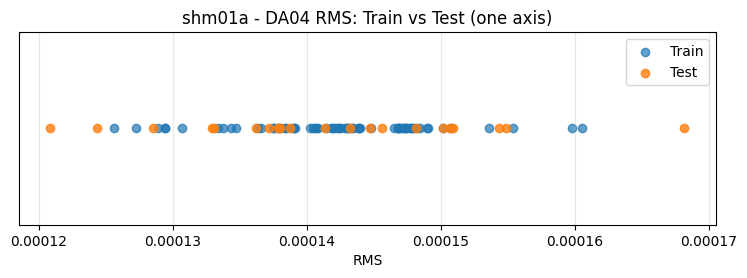

In [ ]:
# ============================================================
# Similarity Audit 2F: One-axis point plot
# shm01a - DA04 RMS
# ============================================================

scenario = 1
feature_idx = 0 # RMS
sensor_idx = 0   # DA04

train_mask = train_audit_meta["scenario"].to_numpy() == scenario
test_mask = test_audit_meta["scenario"].to_numpy() == scenario

train_values = train_features[train_mask, feature_idx, sensor_idx]
test_values = test_features[test_mask, feature_idx, sensor_idx]

plt.figure(figsize=(9, 2.5))

plt.scatter(
    train_values,
    np.zeros(len(train_values)),
    label="Train",
    alpha=0.7
)

plt.scatter(
    test_values,
    np.zeros(len(test_values)),
    label="Test",
    alpha=0.8
)

plt.yticks([])
plt.xlabel("RMS")
plt.title("shm01a - DA04 RMS: Train vs Test (one axis)")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.show()

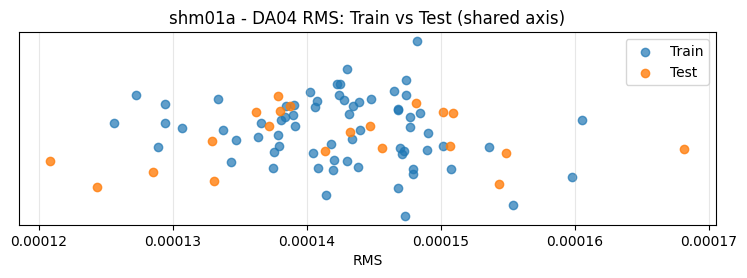

In [ ]:
# Same axis with very small vertical jitter

rng = np.random.default_rng(42)

train_y = rng.normal(0, 0.003, len(train_values))
test_y = rng.normal(0, 0.003, len(test_values))

plt.figure(figsize=(9, 2.5))

plt.scatter(
    train_values,
    train_y,
    label="Train",
    alpha=0.7
)

plt.scatter(
    test_values,
    test_y,
    label="Test",
    alpha=0.8
)

plt.yticks([])
plt.xlabel("RMS")
plt.title("shm01a - DA04 RMS: Train vs Test (shared axis)")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.show()

In [ ]:
# # ============================================================
# # Similarity Audit 2G: KS and Wasserstein
# # Example: shm01a - DA04 RMS
# # ============================================================

# from scipy.stats import ks_2samp, wasserstein_distance

# scenario = 1
# feature_idx = 0   # RMS
# sensor_idx = 0    # DA04

# train_mask = train_audit_meta["scenario"].to_numpy() == scenario
# test_mask = test_audit_meta["scenario"].to_numpy() == scenario

# train_values_scaled = train_features_scaled[
#     train_mask, feature_idx, sensor_idx
# ]

# test_values_scaled = test_features_scaled[
#     test_mask, feature_idx, sensor_idx
# ]

# ks_stat, ks_p = ks_2samp(
#     train_values_scaled,
#     test_values_scaled
# )

# wasserstein = wasserstein_distance(
#     train_values_scaled,
#     test_values_scaled
# )

# print(f"KS statistic:        {ks_stat:.4f}")
# print(f"KS p-value:          {ks_p:.4f}")
# print(f"Wasserstein distance:{wasserstein:.4f}")

In [ ]:
# ============================================================
# Similarity Audit 2H: Distribution comparison
# All scenarios x sensors x features
# ============================================================

from scipy.stats import ks_2samp, wasserstein_distance

distribution_rows = []

for scenario in sorted(train_audit_meta["scenario"].unique()):

    train_mask = (train_audit_meta["scenario"].to_numpy() == scenario)
    test_mask = (test_audit_meta["scenario"].to_numpy() == scenario)
    case_name = train_audit_meta.loc[train_mask, "case"].iloc[0]

    for feature_idx, feature_name in enumerate(feature_names):

        for sensor_idx, sensor_name in enumerate(selected_sensor_names):

            train_values = train_features_scaled[train_mask,feature_idx,sensor_idx]
            test_values = test_features_scaled[test_mask,feature_idx,sensor_idx]
            # KS test
            ks_stat, ks_p = ks_2samp(train_values,test_values)
            # Wasserstein distance
            wasserstein = wasserstein_distance(train_values,test_values)

            distribution_rows.append({
                "case": case_name,
                "scenario": scenario,
                "feature": feature_name,
                "sensor": sensor_name,
                "ks_statistic": ks_stat,
                "ks_p_value": ks_p,
                "wasserstein": wasserstein
            })


distribution_df = pd.DataFrame(distribution_rows)

print("Number of comparisons:", len(distribution_df))

display(distribution_df.head(40))

Number of comparisons: 288


,case,scenario,feature,sensor,ks_statistic,ks_p_value,wasserstein
0,shm01a,1,RMS,DA04,0.212185,3.979022e-01,0.076296
1,shm01a,1,RMS,DA05,0.460784,1.254232e-03,0.157295
2,shm01a,1,RMS,DA07,0.468487,9.443231e-04,0.341084
3,shm01a,1,RMS,DA08,0.416667,4.916764e-03,0.125765
4,shm01a,1,RMS,DA10,0.596639,6.415968e-06,0.009883
5,shm01a,1,RMS,DA11,0.695378,5.012513e-08,1.412899
6,shm01a,1,RMS,DA13,0.193978,5.066023e-01,0.125928
7,shm01a,1,RMS,DA14,0.416667,4.916764e-03,0.123791
8,shm01a,1,STD,DA04,0.212185,3.979022e-01,0.078267
9,shm01a,1,STD,DA05,0.460784,1.254232e-03,0.157246


In [ ]:
# ============================================================
# Similarity Audit 2J: Summary by scenario
# ============================================================

scenario_summary_df = (
    distribution_df
    .groupby(["case", "scenario"])
    .agg(
        mean_ks=("ks_statistic", "mean"),
        median_ks=("ks_statistic", "median"),
        mean_wasserstein=("wasserstein", "mean"),
        median_wasserstein=("wasserstein", "median"),
        significant_percent=(
            "ks_p_value",
            lambda x: 100 * np.mean(x < 0.05)
        )
    )
    .reset_index()
)

display(scenario_summary_df)

,case,scenario,mean_ks,median_ks,mean_wasserstein,median_wasserstein,significant_percent
0,shm01a,1,0.467196,0.460784,0.295292,0.125847,75.000
1,shm02a,2,0.255734,0.256653,0.093656,0.064913,12.500
2,shm03a,3,0.282475,0.303571,0.155263,0.098048,28.125
3,shm04a,4,0.304337,0.253852,0.070540,0.054548,37.500
4,shm05a,5,0.671897,0.807073,0.929188,0.366452,81.250
5,shm06a,6,0.568934,0.613971,0.450834,0.205637,81.250
6,shm07a,7,0.202786,0.190191,0.127777,0.121619,59.375
7,shm08a,8,0.120846,0.109942,0.299792,0.076387,15.625
8,shm09a,9,0.186049,0.181502,0.131506,0.120375,50.000


In [ ]:
# ============================================================
# Similarity Audit 2K: Final Train-Test statistical summary
# Chronological split
# ============================================================

chronological_stat_summary = pd.DataFrame({
    "metric": [
        "Median KS statistic",
        "Mean KS statistic",
        "Median Wasserstein distance",
        "Mean Wasserstein distance"
    ],

    "value": [
        scenario_summary_df["median_ks"].median(),
        scenario_summary_df["mean_ks"].mean(),
        scenario_summary_df["median_wasserstein"].median(),
        scenario_summary_df["mean_wasserstein"].mean()
    ]
})

display(chronological_stat_summary)

,metric,value
0,Median KS statistic,0.256653
1,Mean KS statistic,0.340028
2,Median Wasserstein distance,0.120375
3,Mean Wasserstein distance,0.283761


In [ ]:
# # ============================================================
# # Similarity Audit 3A: Window PSD
# # Example: shm01a - DA04
# # ============================================================

# from scipy.signal import welch

# scenario = 1
# sensor_idx = 0   # DA04

# train_mask = (train_audit_meta["scenario"].to_numpy() == scenario)
# test_mask = (test_audit_meta["scenario"].to_numpy() == scenario)

# X_train_case = X_train_audit[train_mask]
# X_test_case = X_test_audit[test_mask]

# fs = all_cases["shm01a"]["fs"]

# train_psd = []
# test_psd = []

# for window in X_train_case:

#     f, psd = welch(window[:, sensor_idx],fs=fs,nperseg=256,noverlap=128)
#     train_psd.append(psd)

# for window in X_test_case:

#     f, psd = welch(window[:, sensor_idx],fs=fs,nperseg=256,noverlap=128)
#     test_psd.append(psd)


# train_psd = np.array(train_psd)
# test_psd = np.array(test_psd)

# print("Train PSD:", train_psd.shape)
# print("Test PSD: ", test_psd.shape)
# print("Frequency bins:", len(f))

In [ ]:
# ============================================================
# Similarity Audit 3B: Median PSD
# Example: shm01a - DA04
# ============================================================

# train_psd_median = np.median(train_psd, axis=0)
# test_psd_median = np.median(test_psd, axis=0)

# print("Train median PSD:", train_psd_median.shape)
# print("Test median PSD: ", test_psd_median.shape)

In [ ]:
# ============================================================
# Plot Train vs Test median PSD
# ============================================================

# plt.figure(figsize=(9, 4))

# plt.semilogy(f,train_psd_median,label="Train")
# plt.semilogy(f,test_psd_median,label="Test")

# plt.xlabel("Frequency (Hz)")
# plt.ylabel("PSD")
# plt.title("shm01a - DA04: Train vs Test Median PSD")

# plt.legend()
# plt.grid(alpha=0.3)

# plt.show()

In [ ]:
# ============================================================
# Similarity Audit 3C: PSD cosine similarity
# Example: shm01a - DA04
# ============================================================

# from scipy.spatial.distance import cosine

# psd_cosine_similarity = 1 - cosine(train_psd_median,test_psd_median)

# print(f"PSD cosine similarity: " f"{psd_cosine_similarity:.4f}")

In [ ]:
# ============================================================
# Similarity Audit 3D: Log-PSD correlation
# Example: shm01a - DA04
# ============================================================

# eps = 1e-20

# train_log_psd = np.log10(train_psd_median + eps)
# test_log_psd = np.log10(test_psd_median + eps)

# log_psd_corr = np.corrcoef(train_log_psd,test_log_psd)[0, 1]

# print(f"Log-PSD correlation: {log_psd_corr:.4f}")

In [ ]:
# ============================================================
# Similarity Audit 3E: Spectral similarity
# All scenarios x all sensors
# ============================================================

# from scipy.signal import welch
# from scipy.spatial.distance import cosine

# spectral_rows = []

# for scenario in sorted(train_audit_meta["scenario"].unique()):

#     train_mask = train_audit_meta["scenario"].to_numpy() == scenario
#     test_mask = test_audit_meta["scenario"].to_numpy() == scenario

#     X_train_case = X_train_audit[train_mask]
#     X_test_case = X_test_audit[test_mask]

#     case_name = train_audit_meta.loc[
#         train_mask, "case"
#     ].iloc[0]

#     fs = all_cases[case_name]["fs"]

#     for sensor_idx, sensor_name in enumerate(selected_sensor_names):

#         train_psd_list = []
#         test_psd_list = []

#         # Train window PSDs
#         for window in X_train_case:

#             f, psd = welch(
#                 window[:, sensor_idx],
#                 fs=fs,
#                 nperseg=256,
#                 noverlap=128
#             )

#             train_psd_list.append(psd)

#         # Test window PSDs
#         for window in X_test_case:

#             f, psd = welch(
#                 window[:, sensor_idx],
#                 fs=fs,
#                 nperseg=256,
#                 noverlap=128
#             )

#             test_psd_list.append(psd)

#         train_psd_list = np.array(train_psd_list)
#         test_psd_list = np.array(test_psd_list)

#         # Representative PSD for each split
#         train_median_psd = np.median(train_psd_list, axis=0)
#         test_median_psd = np.median(test_psd_list, axis=0)

#         # Cosine similarity
#         cosine_sim = 1 - cosine(
#             train_median_psd,
#             test_median_psd
#         )

#         # Log-PSD correlation
#         eps = 1e-20

#         train_log = np.log10(train_median_psd + eps)
#         test_log = np.log10(test_median_psd + eps)

#         log_corr = np.corrcoef(
#             train_log,
#             test_log
#         )[0, 1]

#         spectral_rows.append({
#             "case": case_name,
#             "scenario": scenario,
#             "sensor": sensor_name,
#             "psd_cosine_similarity": cosine_sim,
#             "log_psd_correlation": log_corr
#         })


# spectral_df = pd.DataFrame(spectral_rows)

# print("Number of spectral comparisons:", len(spectral_df))

# display(spectral_df.head(20))

In [ ]:
# ============================================================
# Similarity Audit 3F: Spectral summary by scenario
# ============================================================

# spectral_scenario_df = (
#     spectral_df
#     .groupby(["case", "scenario"])
#     .agg(
#         mean_psd_cosine=("psd_cosine_similarity", "mean"),
#         median_psd_cosine=("psd_cosine_similarity", "median"),
#         mean_log_psd_corr=("log_psd_correlation", "mean"),
#         median_log_psd_corr=("log_psd_correlation", "median")
#     )
#     .reset_index()
# )

# display(spectral_scenario_df)

In [ ]:
# ============================================================
# Similarity Audit 3G: Final spectral summary
# Chronological split
# ============================================================

# chronological_spectral_summary = pd.DataFrame({
#     "metric": [
#         "Median PSD cosine similarity",
#         "Mean PSD cosine similarity",
#         "Median log-PSD correlation",
#         "Mean log-PSD correlation"
#     ],

#     "value": [
#         spectral_scenario_df["median_psd_cosine"].median(),
#         spectral_scenario_df["mean_psd_cosine"].mean(),
#         spectral_scenario_df["median_log_psd_corr"].median(),
#         spectral_scenario_df["mean_log_psd_corr"].mean()
#     ]
# })

# display(chronological_spectral_summary)

In [ ]:
# print("Window shapes:")
# print("X_train:", X_train.shape)
# print("X_val:  ", X_val.shape)
# print("X_test: ", X_test.shape)

# print("\nLabel shapes:")
# print("y_train:", y_train.shape)
# print("y_val:  ", y_val.shape)
# print("y_test: ", y_test.shape)

In [ ]:
# print("\nTrain class counts:")
# print(pd.Series(y_train).value_counts().sort_index())

# print("\nValidation class counts:")
# print(pd.Series(y_val).value_counts().sort_index())

# print("\nTest class counts:")
# print(pd.Series(y_test).value_counts().sort_index())

In [ ]:
# ============================================================
# Control 3A: 50-Hz diagnostic - DA16
# Train portion only
# ============================================================

In [ ]:
from scipy.signal import welch
import scipy.io as sio
import numpy as np
import pandas as pd


BAND_LOW = 45.0
BAND_HIGH = 50.0

N_PER_SEG = 256
N_OVERLAP = 128


da16_train_data = {}

for file_path in mat_files:

    case_name = file_path.stem

    mat = sio.loadmat(
        file_path,
        squeeze_me=True,
        struct_as_record=False
    )

    fs = float(mat["fsdasy"])

    x = np.asarray(
        getattr(mat["dasy"], "DA16")
    ).reshape(-1)

    # Same chronological Train portion
    train_end = int(TRAIN_RATIO * len(x))
    x_train_raw = x[:train_end]

    # Same high-pass filter
    x_train_filtered = highpass_filter(
        x_train_raw[:, None],
        fs
    )[:, 0]

    # Same edge trimming
    edge_size = int(EDGE_SEC * fs)

    x_train_processed = x_train_filtered[
        edge_size:-edge_size
    ]

    da16_train_data[case_name] = x_train_processed


print("DA16 Train data prepared.")

for case_name in sorted(da16_train_data.keys()):

    print(
        case_name,
        da16_train_data[case_name].shape
    )

DA16 Train data prepared.
shm01a (35200,)
shm02a (35200,)
shm03a (35200,)
shm04a (35200,)
shm05a (35200,)
shm06a (26540,)
shm07a (107200,)
shm08a (107200,)
shm09a (107200,)


In [ ]:
# ============================================================
# Control 3A: DA16 window-level 45-50 Hz power
# ============================================================

da16_50hz_rows = []

for case_name in sorted(da16_train_data.keys()):

    x = da16_train_data[case_name]
    fs = all_cases[case_name]["fs"]

    n_windows = len(x) // WINDOW_SIZE

    for window_idx in range(n_windows):

        start = window_idx * WINDOW_SIZE
        end = start + WINDOW_SIZE

        window = x[start:end]

        f, psd = welch(
            window,
            fs=fs,
            nperseg=N_PER_SEG,
            noverlap=N_OVERLAP
        )

        band_mask = (
            (f >= BAND_LOW) &
            (f <= BAND_HIGH)
        )

        total_mask = (
            (f > 0) &
            (f <= BAND_HIGH)
        )

        band_power = np.trapezoid(
            psd[band_mask],
            f[band_mask]
        )

        total_power = np.trapezoid(
            psd[total_mask],
            f[total_mask]
        )

        relative_band_power = (
            band_power / total_power
            if total_power > 0
            else np.nan
        )

        case_number = int(case_name[3:5])

        session = (
            "Monday"
            if case_number <= 5
            else "Tuesday"
        )

        da16_50hz_rows.append({
            "case": case_name,
            "scenario": case_number,
            "session": session,
            "window": window_idx,
            "band_power_45_50": band_power,
            "relative_power_45_50": relative_band_power
        })


da16_50hz_df = pd.DataFrame(
    da16_50hz_rows
)

print(
    "Number of DA16 windows:",
    len(da16_50hz_df)
)

display(
    da16_50hz_df.head()
)

Number of DA16 windows: 1018


,case,scenario,session,window,band_power_45_50,relative_power_45_50
0,shm01a,1,Monday,0,1.570561e-08,0.067146
1,shm01a,1,Monday,1,1.441487e-08,0.068977
2,shm01a,1,Monday,2,3.140880e-08,0.152217
3,shm01a,1,Monday,3,1.134057e-08,0.059135
4,shm01a,1,Monday,4,1.317388e-08,0.051280


In [ ]:
da16_50hz_summary = (
    da16_50hz_df
    .groupby(
        ["scenario", "case", "session"]
    )
    .agg(
        median_relative_power=(
            "relative_power_45_50",
            "median"
        ),
        q25_relative_power=(
            "relative_power_45_50",
            lambda x: x.quantile(0.25)
        ),
        q75_relative_power=(
            "relative_power_45_50",
            lambda x: x.quantile(0.75)
        )
    )
    .reset_index()
)

display(
    da16_50hz_summary
)

,scenario,case,session,median_relative_power,q25_relative_power,q75_relative_power
0,1,shm01a,Monday,0.081144,0.064330,0.097507
1,2,shm02a,Monday,0.096499,0.082403,0.121394
2,3,shm03a,Monday,0.090154,0.073798,0.115896
3,4,shm04a,Monday,0.087905,0.075349,0.104392
4,5,shm05a,Monday,0.076326,0.055348,0.093552
5,6,shm06a,Tuesday,0.088189,0.075750,0.113120
6,7,shm07a,Tuesday,0.092441,0.073218,0.116131
7,8,shm08a,Tuesday,0.080260,0.065068,0.098740
8,9,shm09a,Tuesday,0.088096,0.068607,0.112404


In [ ]:
# ============================================================
# Control 3B: 45-50 Hz diagnostic on structural sensors
# DA04-DA15, Train only
# ============================================================

structural_50hz_rows = []

structural_sensors = [
    "DA04", "DA05", "DA06",
    "DA07", "DA08", "DA09",
    "DA10", "DA11", "DA12",
    "DA13", "DA14", "DA15"
]

for case_name in sorted(train_data.keys()):

    x = train_data[case_name]
    fs = all_cases[case_name]["fs"]

    n_windows = len(x) // WINDOW_SIZE

    for window_idx in range(n_windows):

        start = window_idx * WINDOW_SIZE
        end = start + WINDOW_SIZE

        window = x[start:end]

        for sensor_name in structural_sensors:

            sensor_idx = CHANNELS.index(sensor_name)

            signal = window[:, sensor_idx]

            f, psd = welch(
                signal,
                fs=fs,
                nperseg=N_PER_SEG,
                noverlap=N_OVERLAP
            )

            band_mask = (
                (f >= BAND_LOW) &
                (f <= BAND_HIGH)
            )

            total_mask = (
                (f > 0) &
                (f <= BAND_HIGH)
            )

            band_power = np.trapezoid(
                psd[band_mask],
                f[band_mask]
            )

            total_power = np.trapezoid(
                psd[total_mask],
                f[total_mask]
            )

            relative_power = (
                band_power / total_power
                if total_power > 0
                else np.nan
            )

            scenario = int(case_name[3:5])

            session = (
                "Monday"
                if scenario <= 5
                else "Tuesday"
            )

            structural_50hz_rows.append({
                "case": case_name,
                "scenario": scenario,
                "session": session,
                "sensor": sensor_name,
                "window": window_idx,
                "band_power_45_50": band_power,
                "total_power_0_50": total_power,
                "relative_power_45_50": relative_power
            })


structural_50hz_df = pd.DataFrame(
    structural_50hz_rows
)

print(
    "Number of rows:",
    len(structural_50hz_df)
)

display(
    structural_50hz_df.head()
)

Number of rows: 12216


,case,scenario,session,sensor,window,band_power_45_50,total_power_0_50,relative_power_45_50
0,shm01a,1,Monday,DA04,0,7.093742e-12,2.241290e-08,0.000317
1,shm01a,1,Monday,DA05,0,2.132145e-10,8.735993e-07,0.000244
2,shm01a,1,Monday,DA06,0,2.004445e-11,1.882951e-08,0.001065
3,shm01a,1,Monday,DA07,0,1.015254e-11,1.397236e-08,0.000727
4,shm01a,1,Monday,DA08,0,1.667806e-11,9.351134e-07,0.000018


In [ ]:
# ============================================================
# Control 3D: Absolute and relative power summary
# ============================================================

stable_sensors = [
    "DA04", "DA05",
    "DA07", "DA08",
    "DA10", "DA11",
    "DA13", "DA14"
]

structural_50hz_df["sensor_group"] = np.where(
    structural_50hz_df["sensor"].isin(stable_sensors),
    "Stable 8",
    "Potentially relocated 4"
)

absolute_power_summary = (
    structural_50hz_df
    .groupby(
        ["scenario", "case", "session", "sensor_group"]
    )
    .agg(
        median_band_power=(
            "band_power_45_50",
            "median"
        ),
        median_total_power=(
            "total_power_0_50",
            "median"
        ),
        median_relative_power=(
            "relative_power_45_50",
            "median"
        )
    )
    .reset_index()
)

display(absolute_power_summary)

,scenario,case,session,sensor_group,median_band_power,median_total_power,median_relative_power
0,1,shm01a,Monday,Potentially relocated 4,1.764478e-11,1.186963e-08,0.002100
1,1,shm01a,Monday,Stable 8,1.086129e-11,4.161818e-08,0.000333
2,2,shm02a,Monday,Potentially relocated 4,1.075572e-11,3.095614e-09,0.003803
3,2,shm02a,Monday,Stable 8,4.769846e-12,4.185259e-09,0.001212
4,3,shm03a,Monday,Potentially relocated 4,9.194663e-12,2.296966e-09,0.004946
5,3,shm03a,Monday,Stable 8,7.156781e-12,4.309197e-09,0.002328
6,4,shm04a,Monday,Potentially relocated 4,9.055919e-12,1.709831e-09,0.006815
7,4,shm04a,Monday,Stable 8,5.469621e-12,3.159389e-09,0.002432
8,5,shm05a,Monday,Potentially relocated 4,2.064937e-11,2.921269e-08,0.001183
9,5,shm05a,Monday,Stable 8,6.829500e-12,4.322215e-08,0.000151


In [ ]:
# ============================================================
# Scenario x sensor summary
# ============================================================

sensor_summary = (
    structural_50hz_df
    .groupby(
        ["scenario", "case", "session", "sensor"]
    )
    ["relative_power_45_50"]
    .median()
    .reset_index(
        name="median_relative_power"
    )
)

display(sensor_summary)

,scenario,case,session,sensor,median_relative_power
0,1,shm01a,Monday,DA04,0.000164
1,1,shm01a,Monday,DA05,0.000604
2,1,shm01a,Monday,DA06,0.001261
3,1,shm01a,Monday,DA07,0.000339
4,1,shm01a,Monday,DA08,0.000034
...,...,...,...,...,...
103,9,shm09a,Tuesday,DA11,0.034158
104,9,shm09a,Tuesday,DA12,0.052240
105,9,shm09a,Tuesday,DA13,0.003449
106,9,shm09a,Tuesday,DA14,0.004551


In [ ]:
# ============================================================
# Robust scenario-level summary
# Median across sensors
# ============================================================

scenario_summary = (
    sensor_summary
    .groupby(
        ["scenario", "case", "session"]
    )
    ["median_relative_power"]
    .median()
    .reset_index(
        name="median_across_sensors"
    )
)

display(scenario_summary)

,scenario,case,session,median_across_sensors
0,1,shm01a,Monday,0.000454
1,2,shm02a,Monday,0.001454
2,3,shm03a,Monday,0.003239
3,4,shm04a,Monday,0.003174
4,5,shm05a,Monday,0.000230
5,6,shm06a,Tuesday,0.000213
6,7,shm07a,Tuesday,0.024646
7,8,shm08a,Tuesday,0.031901
8,9,shm09a,Tuesday,0.013394


In [ ]:
# ============================================================
# Control 3C: Stable vs potentially relocated sensors
# ============================================================

stable_sensors = [
    "DA04", "DA05",
    "DA07", "DA08",
    "DA10", "DA11",
    "DA13", "DA14"
]

potentially_relocated_sensors = [
    "DA06", "DA09",
    "DA12", "DA15"
]

df_compare = structural_50hz_df.copy()

df_compare["sensor_group"] = np.where(
    df_compare["sensor"].isin(stable_sensors),
    "Stable 8",
    "Potentially relocated 4"
)

sensor_group_summary = (
    df_compare
    .groupby(
        ["scenario", "case", "session", "sensor_group"]
    )
    ["relative_power_45_50"]
    .median()
    .reset_index(
        name="median_relative_power"
    )
)

display(
    sensor_group_summary.pivot(
        index=["scenario", "case", "session"],
        columns="sensor_group",
        values="median_relative_power"
    ).reset_index()

    )

sensor_group,scenario,case,session,Potentially relocated 4,Stable 8
0,1,shm01a,Monday,0.002100,0.000333
1,2,shm02a,Monday,0.003803,0.001212
2,3,shm03a,Monday,0.004946,0.002328
3,4,shm04a,Monday,0.006815,0.002432
4,5,shm05a,Monday,0.001183,0.000151
5,6,shm06a,Tuesday,0.001881,0.000177
6,7,shm07a,Tuesday,0.021857,0.020792
7,8,shm08a,Tuesday,0.011803,0.040291
8,9,shm09a,Tuesday,0.008461,0.015893


In [ ]:
absolute_power_summary = (
    structural_50hz_df
    .assign(
        sensor_group=lambda df: np.where(
            df["sensor"].isin(stable_sensors),
            "Stable 8",
            "Potentially relocated 4"
        )
    )
    .groupby(
        ["scenario", "case", "session", "sensor_group"]
    )
    .agg(
        median_band_power=(
            "band_power_45_50",
            "median"
        ),
        median_total_power=(
            "total_power_0_50",
            "median"
        ),
        median_relative_power=(
            "relative_power_45_50",
            "median"
        )
    )
    .reset_index()
)

display(
    absolute_power_summary.pivot(
        index=["scenario", "case", "session"],
        columns="sensor_group",
        values=[
            "median_band_power",
            "median_total_power",
            "median_relative_power"
        ]
    )
)

KeyError: "Column(s) ['band_power_45_50', 'total_power_0_50'] do not exist"

In [ ]:
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# بررسی داده‌ها قبل از Tensor
# ----------------------------
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)


# تعداد داده و برچسب باید برابر باشد
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# بررسی NaN و Inf
assert np.isfinite(X_train).all(), "X_train contains NaN or Inf."
assert np.isfinite(X_val).all(), "X_val contains NaN or Inf."
assert np.isfinite(X_test).all(), "X_test contains NaN or Inf."

print("Data check completed.")

X_train shape: (1018, 512, 8)
X_val shape:   (325, 512, 8)
X_test shape:  (325, 512, 8)
y_train shape: (1018,)
y_val shape:   (325,)
y_test shape:  (325,)
Data check completed.


In [ ]:
# ============================================================
# Step 6: Convert arrays to PyTorch tensors
# ============================================================

import random
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# Reproducibility
# ----------------------------
SPLIT_SEED = None
MODEL_SEED = 42

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Reproducibility for CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Warn if a nondeterministic operation is used
    # Commented out: This can sometimes cause AcceleratorError depending on CUDA setup
    # torch.use_deterministic_algorithms(True,warn_only=True)

set_seed(MODEL_SEED)

# Inputs must be float32
X_train_tensor = torch.from_numpy(X_train.astype(np.float32, copy=False))
X_val_tensor = torch.from_numpy(X_val.astype(np.float32, copy=False))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32, copy=False))


# Labels for CrossEntropyLoss must be int64
y_train_tensor = torch.from_numpy(y_train.astype(np.int64, copy=False))
y_val_tensor = torch.from_numpy(y_val.astype(np.int64, copy=False))
y_test_tensor = torch.from_numpy(y_test.astype(np.int64, copy=False))


print("\nTensor shapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)


Tensor shapes:
X_train_tensor: torch.Size([1018, 512, 8])
y_train_tensor: torch.Size([1018])
X_val_tensor: torch.Size([325, 512, 8])
y_val_tensor: torch.Size([325])
X_test_tensor: torch.Size([325, 512, 8])
y_test_tensor: torch.Size([325])


In [ ]:
# ============================================================
# Create Dataset and DataLoader
# ============================================================

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 64

# برای تکرارپذیری Shuffle داده‌های Train
loader_generator = torch.Generator()
loader_generator.manual_seed(MODEL_SEED)


train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,generator=loader_generator)
val_loader   = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [ ]:
print("Number of train samples:", len(train_dataset))
print("Number of val samples:  ", len(val_dataset))
print("Number of test samples: ", len(test_dataset))

print("\nNumber of train batches:", len(train_loader))
print("Number of val batches:  ", len(val_loader))
print("Number of test batches: ", len(test_loader))


X_batch, y_batch = next(iter(train_loader))

print("\nOne train batch:")
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First 10 labels:", y_batch[:10])

Number of train samples: 1018
Number of val samples:   325
Number of test samples:  325

Number of train batches: 16
Number of val batches:   6
Number of test batches:  6

One train batch:
X_batch shape: torch.Size([64, 512, 8])
y_batch shape: torch.Size([64])
First 10 labels: tensor([4, 8, 8, 6, 6, 7, 2, 1, 8, 8])


In [ ]:
# ============================================================
# Step 7: Define raw time-series Transformer
# Input shape: (batch, time, sensors)
# ============================================================

import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score

# ----------------------------
# Device
# ----------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ----------------------------
# Learnable positional encoding
# ----------------------------
class LearnablePositionalEncoding(nn.Module):

    def __init__(self, seq_len, d_model):
        super().__init__()
        self.position = nn.Parameter(torch.zeros(1, seq_len, d_model))
        nn.init.trunc_normal_(self.position,std=0.02)

    def forward(self, x):
        seq_len = x.shape[1]
        return x + self.position[:, :seq_len, :]

Device: cuda


In [ ]:
import torch.nn as nn

from sklearn.metrics import accuracy_score, f1_score

# --- Added these definitions to ensure the model parameters are defined ---
NUM_CLASSES = 9
SEQ_LEN = WINDOW_SIZE
INPUT_DIM = X_train_tensor.shape[2]
D_MODEL = 64
NUM_HEADS = 8
NUM_LAYERS = 2
DIM_FEEDFORWARD = 64
DROPOUT = 0.1
# --- End of added definitions ---

class TransformerTimeSeriesClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        seq_len,
        num_classes,
        d_model=64,
        num_heads=8,
        num_layers=2,
        dim_feedforward=64,
        dropout=0.10
    ):
        super().__init__()

        self.seq_len = seq_len
        self.d_model = d_model

        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)
        self.final_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model,num_classes)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.pos_embedding, mean=0.0, std=0.02)

    def forward(self, x):
        # x shape: (batch, time, channels)

        x = self.input_projection(x)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.transformer_encoder(x)
        x = self.final_norm(x)
        # Mean pooling over time
        x = x.mean(dim=1)
        logits = self.classifier(x)
        return logits

In [ ]:
set_seed(MODEL_SEED)
model = TransformerTimeSeriesClassifier(
    input_dim=INPUT_DIM,
    seq_len=SEQ_LEN,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(device)

print(model)

# ----------------------------
# Count trainable parameters
# ----------------------------
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTrainable parameters:", count_trainable_parameters(model))


# ----------------------------
# Check one forward pass
# ----------------------------
for xb, yb in train_loader:
    xb = xb.to(device)

    logits = model(xb)

    print("\nInput batch shape:", xb.shape)
    print("Output logits shape:", logits.shape)

    break

TransformerTimeSeriesClassifier(
  (input_projection): Linear(in_features=8, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=64, out_features=9, bias=True)
)

Trainable parameters: 84489

Input batch shape: 

/tmp/ipykernel_17978/43457751.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)


In [ ]:
print("NUM_CLASSES:", NUM_CLASSES)
print("Unique train labels:", np.unique(y_train))
print(pd.Series(y_train).value_counts().sort_index())

NUM_CLASSES: 9
Unique train labels: [0 1 2 3 4 5 6 7 8]
0     68
1     68
2     68
3     68
4     68
5     51
6    209
7    209
8    209
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 8: Loss function and optimizer
# ============================================================

class_counts = torch.bincount(y_train_tensor, minlength=NUM_CLASSES).float()
if torch.any(class_counts == 0):
    raise ValueError("At least one class has no training samples.")

class_weights = (len(y_train_tensor) / (NUM_CLASSES * class_counts))
class_weights = class_weights.to(device)

print("Class counts and weights:")

for class_id in range(NUM_CLASSES):

    print(
        f"Scenario {class_id + 1} | "
        f"count: {int(class_counts[class_id])} | "
        f"weight: {class_weights[class_id].item():.4f}"
    )

Class counts and weights:
Scenario 1 | count: 68 | weight: 1.6634
Scenario 2 | count: 68 | weight: 1.6634
Scenario 3 | count: 68 | weight: 1.6634
Scenario 4 | count: 68 | weight: 1.6634
Scenario 5 | count: 68 | weight: 1.6634
Scenario 6 | count: 51 | weight: 2.2179
Scenario 7 | count: 209 | weight: 0.5412
Scenario 8 | count: 209 | weight: 0.5412
Scenario 9 | count: 209 | weight: 0.5412


In [ ]:
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.0002


In [ ]:
# Reset early stopping
best_val_macro_f1 = -1.0
best_val_loss = float("inf")

best_epoch = 0
best_model_state = None

patience_counter = 0
print("New experiment started")
print("Model_Seed:", MODEL_SEED)
print("Heads:", NUM_HEADS)
print("Dropout:", DROPOUT)

New experiment started
Model_Seed: 42
Heads: 8
Dropout: 0.1


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import copy
import torch

NUM_EPOCHS = 100
PATIENCE = 20
GRAD_CLIP = 1.0
MIN_DELTA = 1e-4

LABELS_ORDER = np.arange(NUM_CLASSES)

transformer_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
}

best_val_macro_f1 = -1.0
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0


def run_one_epoch_transformer(model, data_loader, criterion, optimizer=None, device="cpu"):
    """
    If optimizer is given: training mode
    If optimizer is None: evaluation mode
    """

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_training:
                loss.backward()

                # Gradient clipping helps Transformer training stability
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = total_loss / len(data_loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return avg_loss, acc, macro_f1


for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc, train_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device
    )

    transformer_history["epoch"].append(epoch)
    transformer_history["train_loss"].append(train_loss)
    transformer_history["train_acc"].append(train_acc)
    transformer_history["train_macro_f1"].append(train_macro_f1)
    transformer_history["val_loss"].append(val_loss)
    transformer_history["val_acc"].append(val_acc)
    transformer_history["val_macro_f1"].append(val_macro_f1)

    # Save best model based on validation Macro-F1
    if val_macro_f1 > best_val_macro_f1 + MIN_DELTA:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch # Assign epoch here
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train Macro-F1: {train_macro_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break



Epoch 001 | Train Loss: 2.0468 | Train Acc: 0.2554 | Train Macro-F1: 0.1586 | Val Loss: 1.9109 | Val Acc: 0.1569 | Val Macro-F1: 0.1330
Epoch 005 | Train Loss: 1.0618 | Train Acc: 0.7583 | Train Macro-F1: 0.6307 | Val Loss: 0.8055 | Val Acc: 0.7815 | Val Macro-F1: 0.6648
Epoch 010 | Train Loss: 0.6121 | Train Acc: 0.9047 | Train Macro-F1: 0.9158 | Val Loss: 0.4934 | Val Acc: 0.9108 | Val Macro-F1: 0.9152
Epoch 015 | Train Loss: 0.4323 | Train Acc: 0.9460 | Train Macro-F1: 0.9671 | Val Loss: 0.3377 | Val Acc: 0.9538 | Val Macro-F1: 0.9708
Epoch 020 | Train Loss: 0.1817 | Train Acc: 0.9519 | Train Macro-F1: 0.9724 | Val Loss: 0.2049 | Val Acc: 0.9508 | Val Macro-F1: 0.9597
Epoch 025 | Train Loss: 0.1062 | Train Acc: 0.9676 | Train Macro-F1: 0.9811 | Val Loss: 0.1830 | Val Acc: 0.9569 | Val Macro-F1: 0.9638
Epoch 030 | Train Loss: 0.0714 | Train Acc: 0.9745 | Train Macro-F1: 0.9861 | Val Loss: 0.1375 | Val Acc: 0.9692 | Val Macro-F1: 0.9703
Epoch 035 | Train Loss: 0.0490 | Train Acc: 0.98

In [ ]:
if best_model_state is None:
    raise RuntimeError("No best model was saved.")

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print("Best epoch:",best_epoch)
print("Best validation Macro-F1:",best_val_macro_f1)


Training finished.
Best epoch: 35
Best validation Macro-F1: 0.9719031800080544


In [ ]:
# ============================================================
# Final evaluation control
# ============================================================

# Keep False during development/tuning.
# Set True only for final test evaluation.
RUN_TEST = False

In [ ]:
# ============================================================
# Final evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import pandas as pd
import torch


train_eval_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


def predict_with_model_transformer(
    model,
    data_loader,
    device="cpu"
):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for xb, yb in data_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            preds = torch.argmax(logits,dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_labels, all_preds


def final_evaluate_transformer(
    model,
    data_loader,
    split_name,
    device="cpu"
):

    y_true, y_pred = predict_with_model_transformer(
        model=model,
        data_loader=data_loader,
        device=device
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {split_name} =====")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [ ]:
model.eval()

transformer_train_results = final_evaluate_transformer(
    model,
    train_eval_loader,
    "TRAIN",
    device=device
)

transformer_val_results = final_evaluate_transformer(
    model,
    val_loader,
    "VALIDATION",
    device=device
)


===== TRAIN =====
Accuracy:    0.9892
Macro-F1:    0.9942
Weighted-F1: 0.9892

===== VALIDATION =====
Accuracy:    0.9723
Macro-F1:    0.9719
Weighted-F1: 0.9720


In [ ]:
transformer_test_results = None

if RUN_TEST:

    transformer_test_results = final_evaluate_transformer(
        model,
        test_loader,
        "TEST",
        device=device
    )

else:

    print("\nTest evaluation skipped.")


Test evaluation skipped.


In [ ]:
summary_rows = [
    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            transformer_train_results["split"],
        "accuracy":
            transformer_train_results["accuracy"],
        "macro_f1":
            transformer_train_results["macro_f1"],
        "weighted_f1":
            transformer_train_results["weighted_f1"]
    },

    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            transformer_val_results["split"],
        "accuracy":
            transformer_val_results["accuracy"],
        "macro_f1":
            transformer_val_results["macro_f1"],
        "weighted_f1":
            transformer_val_results["weighted_f1"]
    }
]

In [ ]:
if RUN_TEST:

    summary_rows.append(
        {
            "model": "Raw Transformer",
            "preprocessing":
                "Butterworth high-pass + Train-based normalization",
            "selected_sensors":
                len(selected_sensor_names),
            "split":
                transformer_test_results["split"],
            "accuracy":
                transformer_test_results["accuracy"],
            "macro_f1":
                transformer_test_results["macro_f1"],
            "weighted_f1":
                transformer_test_results["weighted_f1"]
        }
    )

In [ ]:
transformer_summary_results = pd.DataFrame(summary_rows)
display(transformer_summary_results)

,model,preprocessing,selected_sensors,split,accuracy,macro_f1,weighted_f1
0,Raw Transformer,Butterworth high-pass + Train-based normalization,8,TRAIN,0.989194,0.994174,0.989235
1,Raw Transformer,Butterworth high-pass + Train-based normalization,8,VALIDATION,0.972308,0.971903,0.971955


In [ ]:
# ============================================================
# Step 11: Test confusion matrix
# ============================================================


if RUN_TEST:

    y_true_test = (
        transformer_test_results["y_true"]
    )

    y_pred_test = (
        transformer_test_results["y_pred"]
    )

    cm_transformer_test = confusion_matrix(
        y_true_test,
        y_pred_test,
        labels=np.arange(NUM_CLASSES)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_transformer_test,
        display_labels=[
            f"S{i+1}"
            for i in range(NUM_CLASSES)
        ]
    )

    disp.plot(
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    plt.title(
        "Test Confusion Matrix"
    )

    plt.grid(False)
    plt.show()

In [ ]:
# Chronological + High-pass + Raw Transformer + 12 sensors

# Test Accuracy    = 0.9892 ± 0.0018
# Test Macro-F1    = 0.9930 ± 0.0021
# Test Weighted-F1 = 0.9893 ± 0.0018

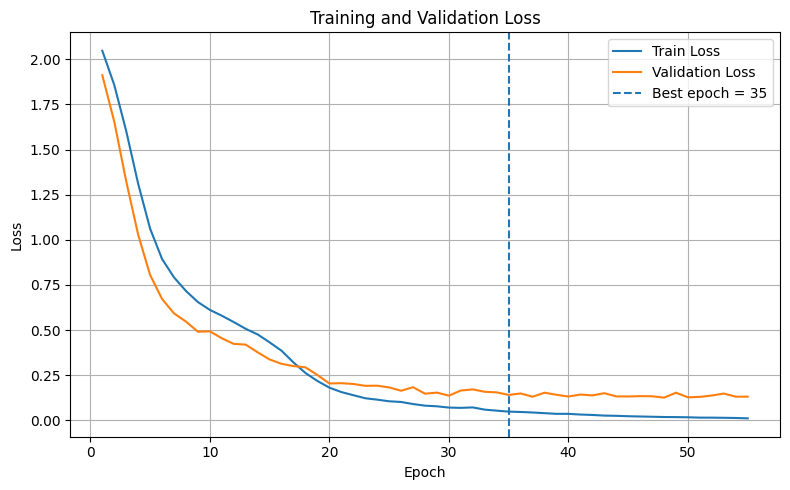

In [ ]:
# ============================================================
# Step 12: Training curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

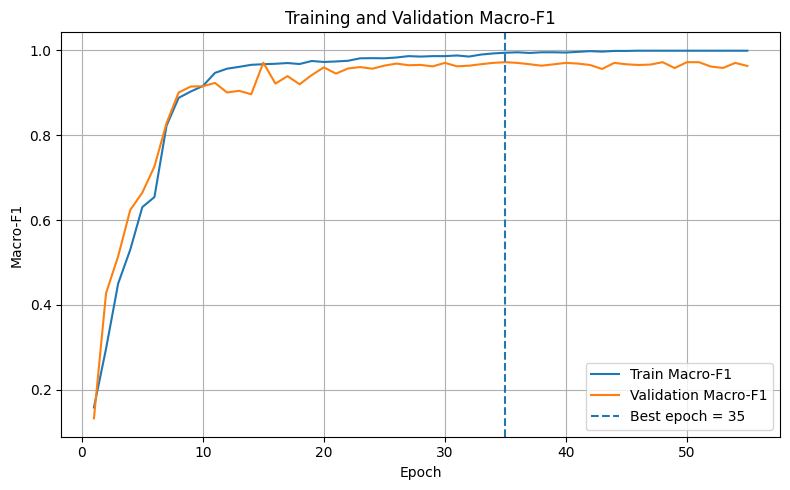

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training and Validation Macro-F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()